## “How did COVID-19 impact regional house price dispersion across UK counties?”
### Notebook 2 - Data Analysis

Data has been cleaned and prepared in Notebook 1 to give a full dataset across counties from 2005-2025.

1. Import cleaned dataset
2. 

In [2]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates

#### Import cleaned dataset

In [7]:
filepath = "../data/house_prices_full_cleaned.csv"
data = pd.read_csv(filepath)
data.head()

,County,Date,AreaCode,AveragePrice,Country,Region
0,Aberdeenshire,2005-01-01,S12000034,105489.0,S,Scotland
1,Aberdeenshire,2005-02-01,S12000034,101145.0,S,Scotland
2,Aberdeenshire,2005-03-01,S12000034,98196.0,S,Scotland
3,Aberdeenshire,2005-04-01,S12000034,99302.0,S,Scotland
4,Aberdeenshire,2005-05-01,S12000034,105412.0,S,Scotland


### Pivot tables for average prices, county v date
Look at a pivot table arranged with counties and dates for average prices.

In [10]:
df_county_date = data.pivot_table(index='County',columns='Date',values='AveragePrice')
df_county_date

Date,2005-01-01,2005-02-01,2005-03-01,2005-04-01,2005-05-01,2005-06-01,2005-07-01,2005-08-01,2005-09-01,2005-10-01,...,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01
County,,,,,,,,,,,,,,,,,,,,,
Aberdeenshire,105489.0,101145.0,98196.0,99302.0,105412.0,110561.0,112337.0,116017.0,117748.0,120861.0,...,193731.0,193159.0,196734.0,200115.0,201317.0,202951.0,201831.0,203136.0,201555.0,202362.0
Adur,183493.0,175825.0,178438.0,179535.0,183259.0,182181.0,179850.0,182674.0,184383.0,186795.0,...,372721.0,373551.0,376763.0,382977.0,378576.0,381370.0,382180.0,374865.0,372499.0,370708.0
Amber Valley,121782.0,122847.0,122490.0,126003.0,126294.0,129078.0,127970.0,126297.0,124372.0,123671.0,...,224300.0,223602.0,224311.0,224192.0,226413.0,230680.0,235285.0,238335.0,238246.0,234786.0
Angus,77436.0,77196.0,78040.0,81245.0,87424.0,89842.0,93388.0,94242.0,96509.0,97747.0,...,165304.0,166294.0,168141.0,170387.0,170632.0,167862.0,165145.0,167542.0,170210.0,174680.0
Antrim and Newtownabbey,107491.0,107491.0,107491.0,107298.0,107298.0,107298.0,116139.0,116139.0,116139.0,120436.0,...,189792.0,189463.0,189463.0,189463.0,195765.0,195765.0,195765.0,197918.0,197918.0,197918.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Wychavon,193661.0,192912.0,189999.0,187074.0,191725.0,194765.0,196859.0,195475.0,197418.0,197194.0,...,322202.0,317768.0,312704.0,314726.0,324802.0,330999.0,333782.0,331721.0,336679.0,333519.0
Wyre,137174.0,134850.0,132668.0,133198.0,135366.0,138126.0,141574.0,141390.0,140024.0,138041.0,...,191156.0,186363.0,183547.0,178896.0,183701.0,187061.0,188731.0,187052.0,187997.0,193044.0
Wyre Forest,138423.0,138375.0,139305.0,139231.0,142268.0,145143.0,150411.0,149447.0,148667.0,144913.0,...,232425.0,229063.0,229142.0,229485.0,236782.0,238175.0,236339.0,235202.0,233338.0,234081.0


### Plot an example of the data
Take one county and plot it, to see an example of the data.

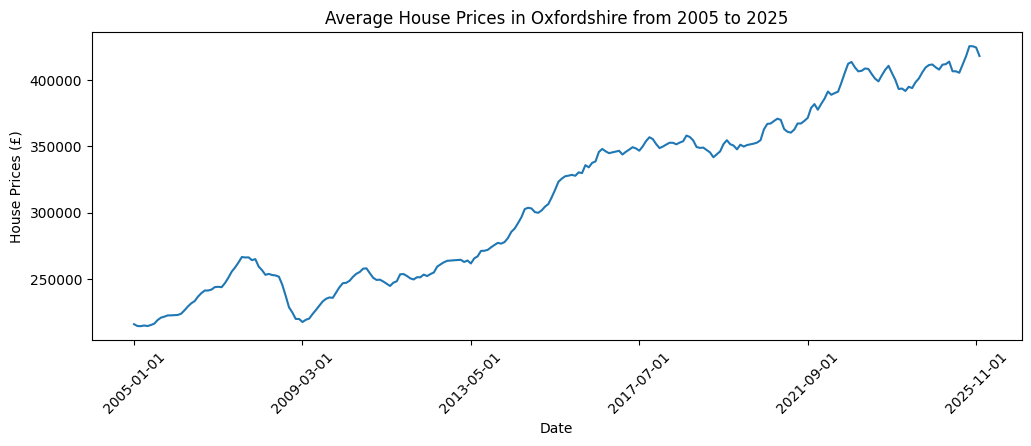

In [34]:
oxfordshire_data = df_county_date.loc['Oxfordshire']
oxfordshire_data.plot(figsize=(12,4))
plt.ylabel('House Prices (£)')
plt.title('Average House Prices in Oxfordshire from 2005 to 2025')
plt.tick_params(axis='x',rotation=45)
plt.show()


In [38]:
max_prices_per_county = df_county_date.T.max().sort_values(ascending=False)
max_prices_per_county

County
Kensington and Chelsea        1656986.0
City of Westminster           1224972.0
City of London                1021539.0
Camden                         948480.0
Hammersmith and Fulham         889834.0
                                ...    
East Ayrshire                  134249.0
City of Kingston upon Hull     132176.0
Burnley                        131476.0
West Dunbartonshire            131097.0
Inverclyde                     121039.0
Length: 405, dtype: float64

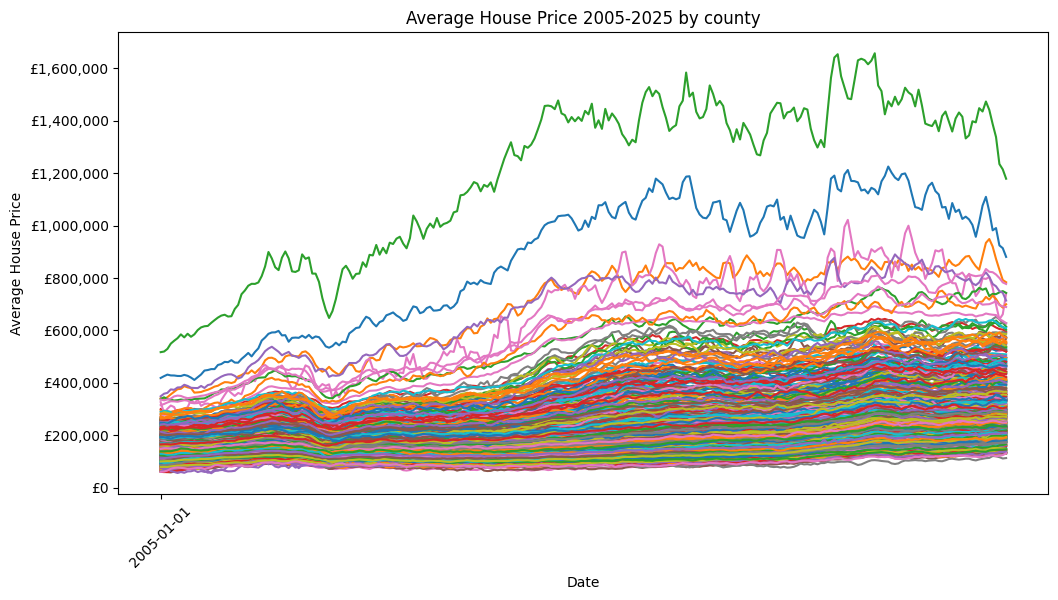

In [46]:
fig,ax = plt.subplots(figsize=(12,6))

ax.plot(df_county_date.T)

ax.set_ylabel('Average House Price')
ax.set_xlabel('Date')
ax.set_title('Average House Price 2005-2025 by county')
ax.ticklabel_format(style='plain',axis='y')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.tick_params(axis='x',rotation=45)
#ax.annotate('Kensington and Chelsea',xy=(pd.Timestamp('2017'),1600000))
#ax.annotate('City of Westminster',xy=(pd.Timestamp('2017'),1200000))

plt.show()